#  Retail Sales Clustering
## Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

rfm = pd.read_csv('rfm_clustered.csv')
print(rfm.shape)
rfm.head(3)

(3913, 7)


,CustomerID,Recency,Frequency,Monetary,KMeans_Cluster,DBSCAN_Cluster,Segment
0,12346.0,282,1,77183.60,1,-1,Champions
1,12347.0,86,5,2790.86,1,0,Champions
2,12348.0,31,4,1797.24,1,0,Champions


In [2]:
#  Re-create scaled features
rfm_feat = rfm[['Recency','Frequency','Monetary']].copy()
rfm_feat['Frequency'] = np.log1p(rfm_feat['Frequency'])
rfm_feat['Monetary']  = np.log1p(rfm_feat['Monetary'])
X = StandardScaler().fit_transform(rfm_feat)

In [4]:
#  Internal Validation Metrics
labels = rfm['KMeans_Cluster'].values

sil  = silhouette_score(X, labels)
dbi  = davies_bouldin_score(X, labels)
chi  = calinski_harabasz_score(X, labels)

print(' Clustering Evaluation Metrics ')
print(f'Silhouette Score       : {sil:.4f}  (↑ higher better, max 1.0)')
print(f'Davies-Bouldin Index   : {dbi:.4f}  (↓ lower better, min 0)')
print(f'Calinski-Harabász Index: {chi:.2f} (↑ higher better)')

 Clustering Evaluation Metrics 
Silhouette Score       : 0.3616  (↑ higher better, max 1.0)
Davies-Bouldin Index   : 0.9099  (↓ lower better, min 0)
Calinski-Harabász Index: 3638.23 (↑ higher better)


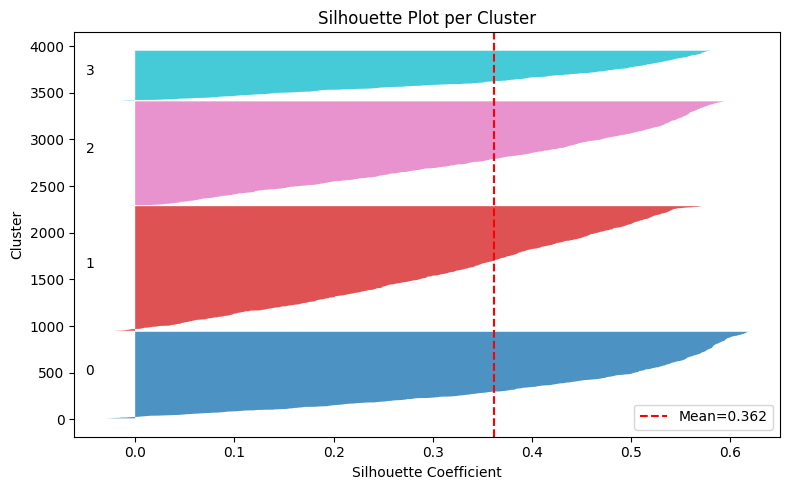

In [5]:
# Per-Sample Silhouette Plot
from sklearn.metrics import silhouette_samples

sil_vals  = silhouette_samples(X, labels)
n_clusters = rfm['KMeans_Cluster'].nunique()

fig, ax = plt.subplots(figsize=(8, 5))
y_lower = 10
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    vals = np.sort(sil_vals[labels == i])
    y_upper = y_lower + len(vals)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                     facecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + len(vals) / 2, str(i))
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', label=f'Mean={sil:.3f}')
ax.set_title('Silhouette Plot per Cluster')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=100)
plt.show()

In [6]:
#  Compare KMeans k=2..8 across all metrics
results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X)
    results.append({
        'k'          : k,
        'Silhouette' : round(silhouette_score(X, lbl), 4),
        'DBI'        : round(davies_bouldin_score(X, lbl), 4),
        'CHI'        : round(calinski_harabasz_score(X, lbl), 2)
    })

metrics_df = pd.DataFrame(results)
print(metrics_df.to_string(index=False))

 k  Silhouette    DBI     CHI
 2      0.3986 0.9326 3371.83
 3      0.3956 0.8702 3754.54
 4      0.3616 0.9099 3638.23
 5      0.3342 0.9771 3329.78
 6      0.3227 0.9701 3216.39
 7      0.3198 0.9443 3073.80
 8      0.2963 1.0059 2951.81


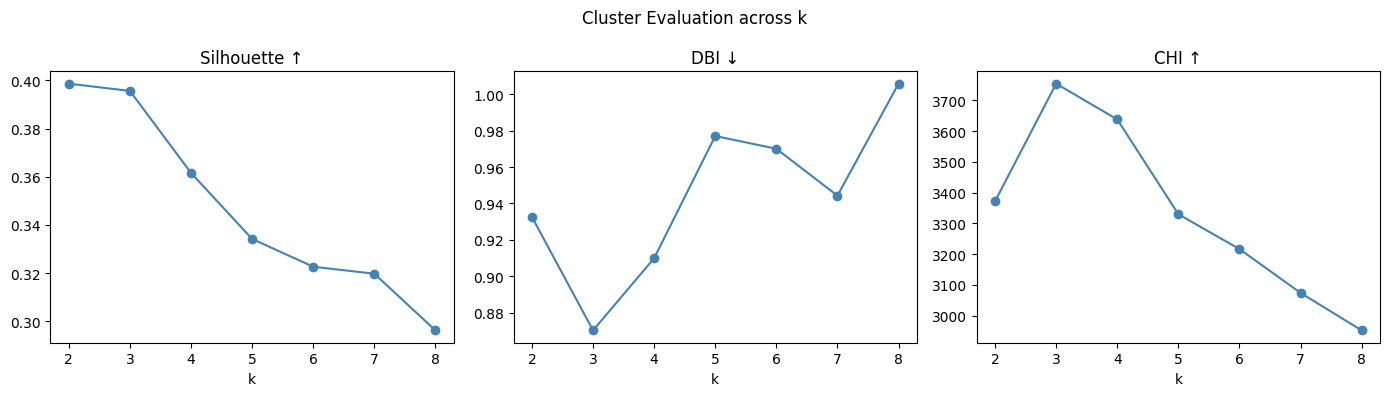

In [7]:
#  Plot metric comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, up in zip(axes,
                       ['Silhouette', 'DBI', 'CHI'],
                       ['↑', '↓', '↑']):
    axes[['Silhouette','DBI','CHI'].index(col)].plot(
        metrics_df['k'], metrics_df[col], marker='o', color='steelblue')
    ax.set_title(f'{col} {up}'); ax.set_xlabel('k')
plt.suptitle('Cluster Evaluation across k')
plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=100)
plt.show()

                     Count   Avg_R  Avg_F    Avg_M     Total_M  Revenue_%
Segment                                                                  
At-Risk                929  236.93   1.29   363.51   337705.03        4.8
Champions             1337   52.50   3.56  1437.25  1921603.78       27.3
Lost/Inactive          533   27.11  13.58  8245.93  4395078.64       62.5
Potential Loyalists   1114   57.37   1.36   342.39   381419.92        5.4


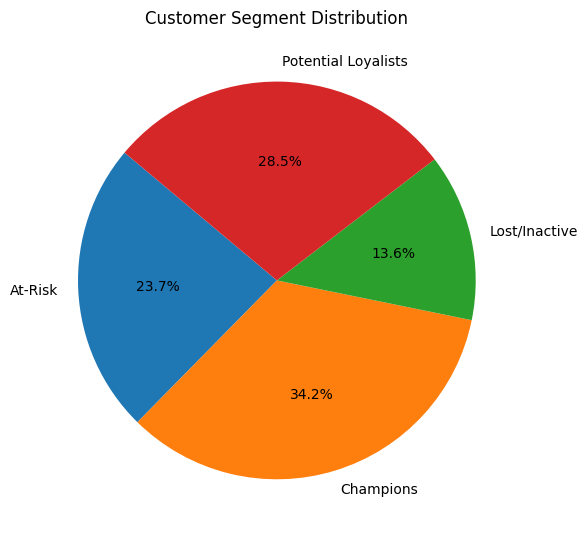

In [8]:
#  Cluster Size & Revenue Contribution
summary = rfm.groupby('Segment').agg(
    Count    = ('CustomerID','count'),
    Avg_R    = ('Recency','mean'),
    Avg_F    = ('Frequency','mean'),
    Avg_M    = ('Monetary','mean'),
    Total_M  = ('Monetary','sum')
).round(2)
summary['Revenue_%'] = (summary['Total_M'] / summary['Total_M'].sum() * 100).round(1)
print(summary)

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(summary['Count'], labels=summary.index, autopct='%1.1f%%',
        startangle=140)
plt.title('Customer Segment Distribution')
plt.tight_layout()
plt.savefig('segment_pie.png', dpi=100)
plt.show()

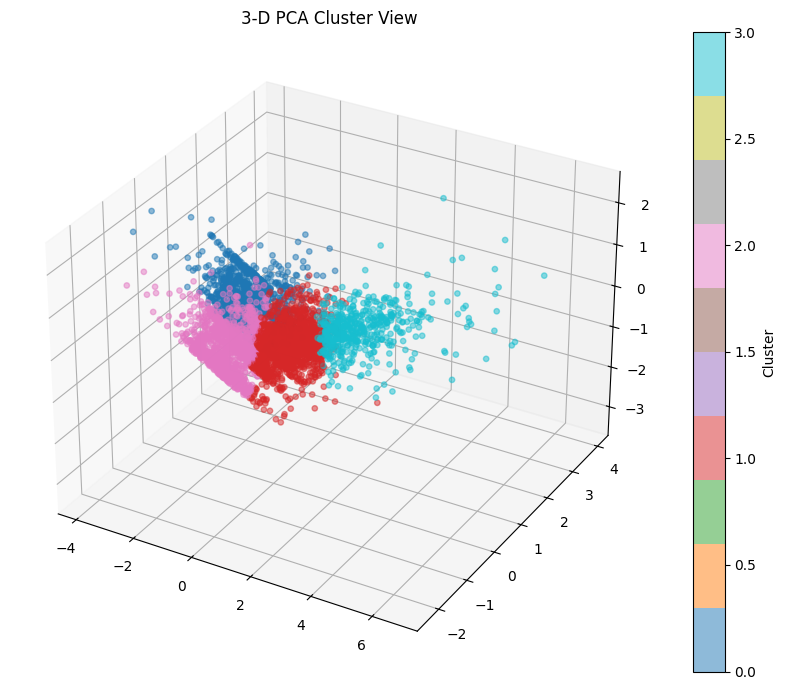

3 PCs explain 100.00% variance


In [9]:
#  3-D PCA Scatter
pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X)

fig = plt.figure(figsize=(9, 7))
ax  = fig.add_subplot(111, projection='3d')
sc  = ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2],
                 c=rfm['KMeans_Cluster'], cmap='tab10', alpha=0.5, s=15)
plt.colorbar(sc, label='Cluster')
ax.set_title('3-D PCA Cluster View')
plt.tight_layout()
plt.savefig('pca3d_clusters.png', dpi=100)
plt.show()
print(f'3 PCs explain {pca3.explained_variance_ratio_.sum():.2%} variance')

In [10]:
# Final Summary
print('Final Evaluation Summary')
print(f'Chosen k             : 4')
print(f'Silhouette Score     : {sil:.4f}')
print(f'Davies-Bouldin Index : {dbi:.4f}')
print(f'Calinski-Harabász   : {chi:.2f}')
print()
print('Segment Revenue Contribution:')
print(summary[['Count','Total_M','Revenue_%']])

Final Evaluation Summary
Chosen k             : 4
Silhouette Score     : 0.3616
Davies-Bouldin Index : 0.9099
Calinski-Harabász   : 3638.23

Segment Revenue Contribution:
                     Count     Total_M  Revenue_%
Segment                                          
At-Risk                929   337705.03        4.8
Champions             1337  1921603.78       27.3
Lost/Inactive          533  4395078.64       62.5
Potential Loyalists   1114   381419.92        5.4
